# Cross Comparrisons 

In [100]:
# imports and config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, re
from collections import Counter
from urllib.parse import urlparse


# topic / sentiment 

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from bertopic import BERTopic
from sklearn.metrics import classification_report, cohen_kappa_score

plt.style.use('seaborn-v0_8-colorblind')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
c_bsky = colors[0]
c_truth = colors[1]
CLEAN = 'clean'

## Data Loading

In [52]:
# load aligned datasets
bsky = pd.read_csv(f'{CLEAN}/bsky_aligned.csv')
truth = pd.read_csv(f'{CLEAN}/truth_aligned.csv', dtype={'post_id': str})
bsky['created_at'] = pd.to_datetime(bsky['created_at'], format='mixed', utc=True)
truth['created_at'] = pd.to_datetime(truth['created_at'], format='mixed', utc=True)


# align timeline
start = pd.Timestamp('2023-02-01', tz='UTC')
end = pd.Timestamp('2026-05-29', tz='UTC')
bsky = bsky[(bsky['created_at'] >= start) & (bsky['created_at'] <= end)]
truth = truth[(truth['created_at'] >= start) & (truth['created_at'] <= end)]
print(f"After timeline alignment: Bluesky {len(bsky):,}  |  Truth {len(truth):,}")

bsky.to_csv('clean/bsky_aligned.csv', index=False)
truth.to_csv('clean/truth_aligned.csv', index=False)

# compute engagement
bsky['total_engagement'] = bsky['like_count'] + bsky['repost_count'] + bsky['reply_count']
truth['total_engagement'] = truth['like_count'] + truth['retruth_count'] + truth['reply_count']

# create aligned top 5% engagement subsets
bsky_thresh = bsky['total_engagement'].quantile(0.95)
truth_thresh = truth['total_engagement'].quantile(0.95)
bsky_top = bsky[bsky['total_engagement'] >= bsky_thresh].reset_index(drop=True)
truth_top = truth[truth['total_engagement'] >= truth_thresh].reset_index(drop=True)

# merge sentiment into top engagement
bsky_sent = pd.read_csv(f'{CLEAN}/bsky_top_sentiment.csv')
bsky_emo = pd.read_csv(f'{CLEAN}/bsky_top_emotions.csv')
bsky_top = bsky_top.merge(bsky_sent, on='post_uri', how='left')
bsky_top = bsky_top.merge(bsky_emo, on='post_uri', how='left')

truth_sent = pd.read_csv(f'{CLEAN}/truth_top_sentiment.csv', dtype={'post_id': str})
truth_emo = pd.read_csv(f'{CLEAN}/truth_top_emotions.csv', dtype={'post_id': str})
truth_top = truth_top.merge(truth_sent, on='post_id', how='left')
truth_top = truth_top.merge(truth_emo, on='post_id', how='left')

# merge topics into top engagement
bsky_topics = pd.read_csv(f'{CLEAN}/bsky_top_topics.csv')
truth_topics = pd.read_csv(f'{CLEAN}/truth_top_topics.csv', dtype={'post_id': str})
bsky_top = bsky_top.merge(bsky_topics, on='post_uri', how='left')
truth_top = truth_top.merge(truth_topics, on='post_id', how='left')

print(f"Aligned full     Bluesky: {len(bsky):,}  |  Truth Social: {len(truth):,}")
print(f"Aligned top 5%   Bluesky: {len(bsky_top):,}  |  Truth Social: {len(truth_top):,}")
print(f"Engagement threshold Bluesky: >= {bsky_thresh:.0f}  |  Truth Social: >= {truth_thresh:.0f}")
print(f"Sentiment coverage Bluesky: {bsky_top['label'].notna().sum():,}/{len(bsky_top):,}  |  Truth: {truth_top['label'].notna().sum():,}/{len(truth_top):,}")
print(f"Timeline: {bsky['created_at'].min().strftime('%Y-%m-%d')} to {bsky['created_at'].max().strftime('%Y-%m-%d')}")

After timeline alignment: Bluesky 75,996  |  Truth 39,759
Aligned full     Bluesky: 75,996  |  Truth Social: 39,759
Aligned top 5%   Bluesky: 3,803  |  Truth Social: 2,013
Engagement threshold Bluesky: >= 426  |  Truth Social: >= 11
Sentiment coverage Bluesky: 3,803/3,803  |  Truth: 2,013/2,013
Timeline: 2023-03-10 to 2026-05-28


## Dataset Overview

In [53]:
# overview table
overview = pd.DataFrame({
    'Metric': [
        'Full corpus (pre-alignment)',
        'Aligned posts (shared terms + timeline)',
        'Aligned top 5% engagement',
        'Unique authors (aligned)',
        'Date range',
        'Collection method',
        'Shared search terms',
        'Engagement threshold',
        'Median engagement (aligned)',
    ],
    'Bluesky': [
        '1,529,104',
        f'{len(bsky):,}',
        f'{len(bsky_top):,}',
        f"{bsky['author_did'].nunique():,}",
        f"{bsky['created_at'].min().strftime('%Y-%m-%d')} to {bsky['created_at'].max().strftime('%Y-%m-%d')}",
        'Full-text keyword search (AT Protocol)',
        '19',
        f">= {bsky_thresh:.0f}",
        f"{bsky['total_engagement'].median():.0f}",
    ],
    'Truth Social': [
        '48,086',
        f'{len(truth):,}',
        f'{len(truth_top):,}',
        f"{truth['author_id'].nunique():,}",
        f"{truth['created_at'].min().strftime('%Y-%m-%d')} to {truth['created_at'].max().strftime('%Y-%m-%d')}",
        'Hashtag timeline (Mastodon API)',
        '19',
        f">= {truth_thresh:.0f}",
        f"{truth['total_engagement'].median():.0f}",
    ]
})
print(overview.to_string(index=False))

                                 Metric                                Bluesky                    Truth Social
            Full corpus (pre-alignment)                              1,529,104                          48,086
Aligned posts (shared terms + timeline)                                 75,996                          39,759
              Aligned top 5% engagement                                  3,803                           2,013
               Unique authors (aligned)                                 24,808                           4,630
                             Date range               2023-03-10 to 2026-05-28        2023-02-01 to 2026-05-19
                      Collection method Full-text keyword search (AT Protocol) Hashtag timeline (Mastodon API)
                    Shared search terms                                     19                              19
                   Engagement threshold                                 >= 426                           >= 11
 

## Keyword / Hashtag Volume

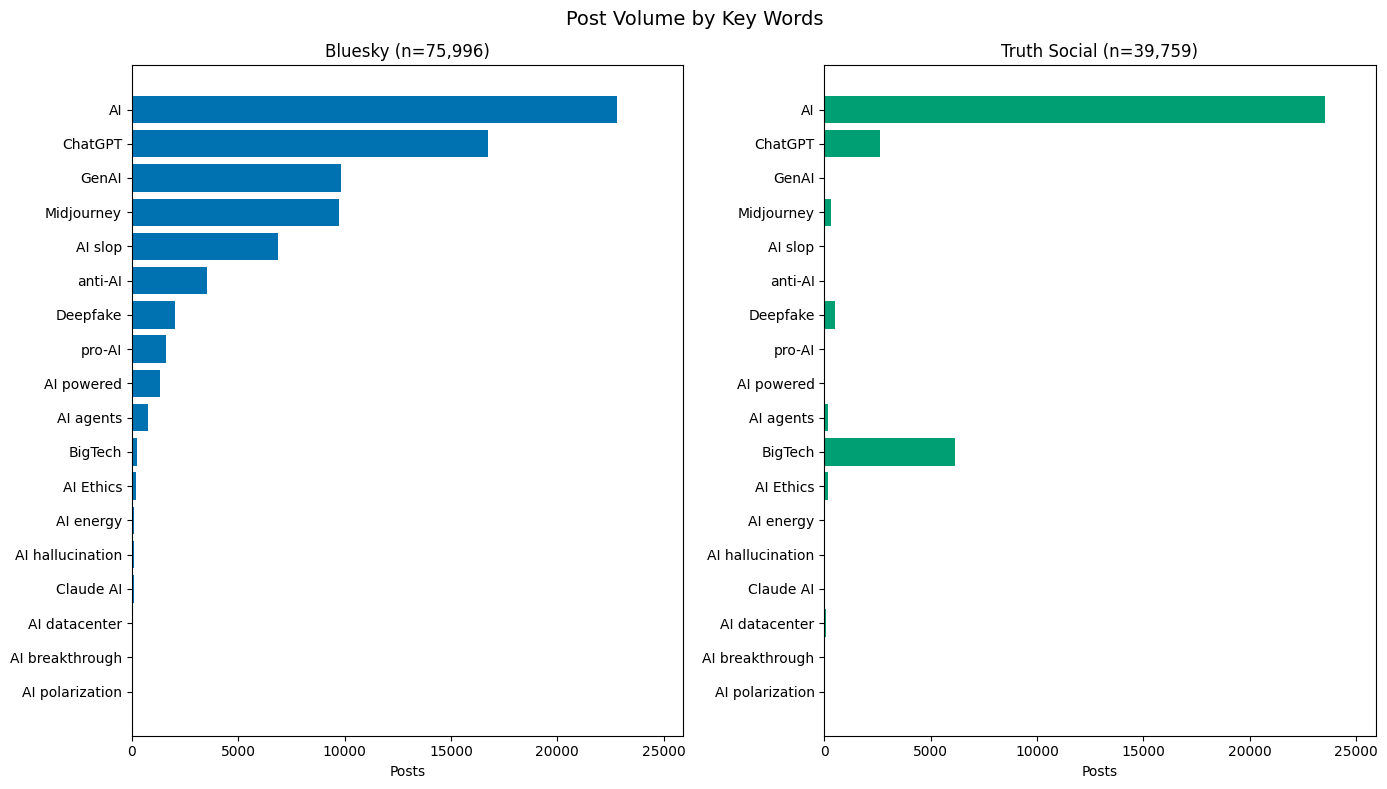

In [71]:
# convert hashtag to keyword
TRUTH_LABEL_MAP = {
    'AI': 'AI', 'ChatGPT': 'ChatGPT', 'GenAI': 'GenAI', 'Midjourney': 'Midjourney',
    'AIslop': 'AI slop', 'antiAI': 'anti-AI', 'deepfake': 'Deepfake',
    'proAI': 'pro-AI', 'AIpowered': 'AI powered', 'AIagents': 'AI agents',
    'BigTech': 'BigTech', 'AIethics': 'AI Ethics', 'AIenergy': 'AI energy',
    'AIhallucination': 'AI hallucination', 'ClaudeAI': 'Claude AI',
    'AIdatacenter': 'AI datacenter', 'AIbreakthrough': 'AI breakthrough',
    'AIpolarization': 'AI polarization', 'ArtificialIntelligence': 'Artificial Intelligence',
}

truth['display_term'] = truth['hashtag'].map(TRUTH_LABEL_MAP)

# shared sort order by Bluesky volume
term_order = bsky['search_keyword'].value_counts().index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

bsky_kw = bsky['search_keyword'].value_counts().reindex(term_order)
ax1.barh(bsky_kw.index[::-1], bsky_kw.values[::-1], color=c_bsky)
ax1.set_title(f'Bluesky (n={len(bsky):,})')
ax1.set_xlabel('Posts')

truth_kw = truth['display_term'].value_counts().reindex(term_order, fill_value=0)
ax2.barh(truth_kw.index[::-1], truth_kw.values[::-1], color=c_truth)
ax2.set_title(f'Truth Social (n={len(truth):,})')
ax2.set_xlabel('Posts')

max_x = max(bsky_kw.max(), truth_kw.max()) * 1.1
ax1.set_xlim(0, max_x)
ax2.set_xlim(0, max_x)

plt.suptitle('Post Volume by Key Words', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_keyword_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## Post volume over time in relation to key events

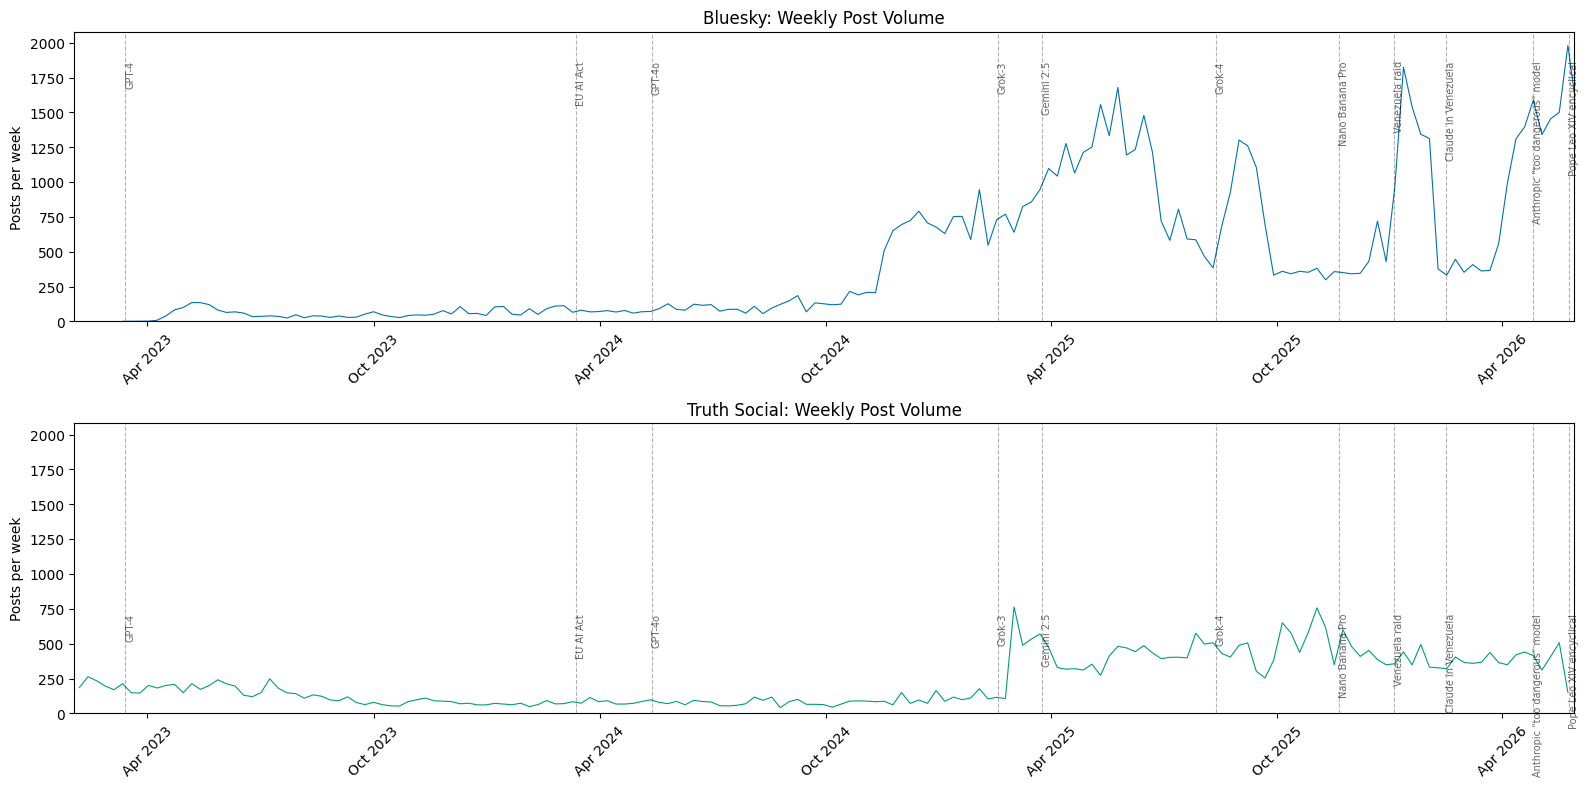

In [77]:
# events timeline
AI_EVENTS = {
    '2023-03-14': 'GPT-4',
    '2024-03-13': 'EU AI Act',
    '2024-05-13': 'GPT-4o',
    '2025-02-17': 'Grok-3',
    '2025-03-25': 'Gemini 2.5',
    '2025-08-12': 'Grok-4',
    '2025-11-20': 'Nano Banana Pro',
    '2026-01-03': 'Venezuela raid',
    '2026-02-14': 'Claude in Venezuela',
    '2026-04-26': 'Anthropic "too dangerous" model',
    '2026-05-25': 'Pope Leo XIV encyclical',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))

# both start at Bluesky inception
start_date = pd.Timestamp('2023-02-01').to_pydatetime()
end_date = pd.Timestamp('2026-05-29').to_pydatetime()

for ax, df, name, color in [(ax1, bsky, 'Bluesky', c_bsky), (ax2, truth, 'Truth Social', c_truth)]:
    weekly = df.set_index('created_at').resample('W').size()
    dates = weekly.index.tz_localize(None).to_pydatetime()
    ax.plot(dates, weekly.values, linewidth=0.8, color=color)
    ax.set_title(f'{name}: Weekly Post Volume')
    ax.set_ylabel('Posts per week')
    ax.set_xlim(start_date, end_date)

    for date_str, label in AI_EVENTS.items():
        dt = pd.Timestamp(date_str).to_pydatetime()
        ax.axvline(dt, color='black', alpha=0.3, linewidth=0.8, linestyle='--')
        ax.text(dt, ax.get_ylim()[1] * 0.9, label, rotation=90, fontsize=7, alpha=0.6, va='top')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# same y-axis scale
max_y = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(0, max_y)
ax2.set_ylim(0, max_y)

plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_volume_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Sentiment Analysis

In [56]:
# sentiment distribution table — aligned top 5%
sent_table = pd.DataFrame({
    'Sentiment': ['Negative', 'Neutral', 'Positive'],
    'Bluesky (n)': [
        f"{(bsky_top['label']=='negative').sum():,}",
        f"{(bsky_top['label']=='neutral').sum():,}",
        f"{(bsky_top['label']=='positive').sum():,}",
    ],
    'Bluesky (%)': [
        f"{(bsky_top['label']=='negative').mean()*100:.1f}%",
        f"{(bsky_top['label']=='neutral').mean()*100:.1f}%",
        f"{(bsky_top['label']=='positive').mean()*100:.1f}%",
    ],
    'Truth (n)': [
        f"{(truth_top['label']=='negative').sum():,}",
        f"{(truth_top['label']=='neutral').sum():,}",
        f"{(truth_top['label']=='positive').sum():,}",
    ],
    'Truth (%)': [
        f"{(truth_top['label']=='negative').mean()*100:.1f}%",
        f"{(truth_top['label']=='neutral').mean()*100:.1f}%",
        f"{(truth_top['label']=='positive').mean()*100:.1f}%",
    ],
})
print(sent_table.to_string(index=False))

Sentiment Bluesky (n) Bluesky (%) Truth (n) Truth (%)
 Negative       2,354       61.9%       769     38.2%
  Neutral       1,005       26.4%       914     45.4%
 Positive         444       11.7%       330     16.4%


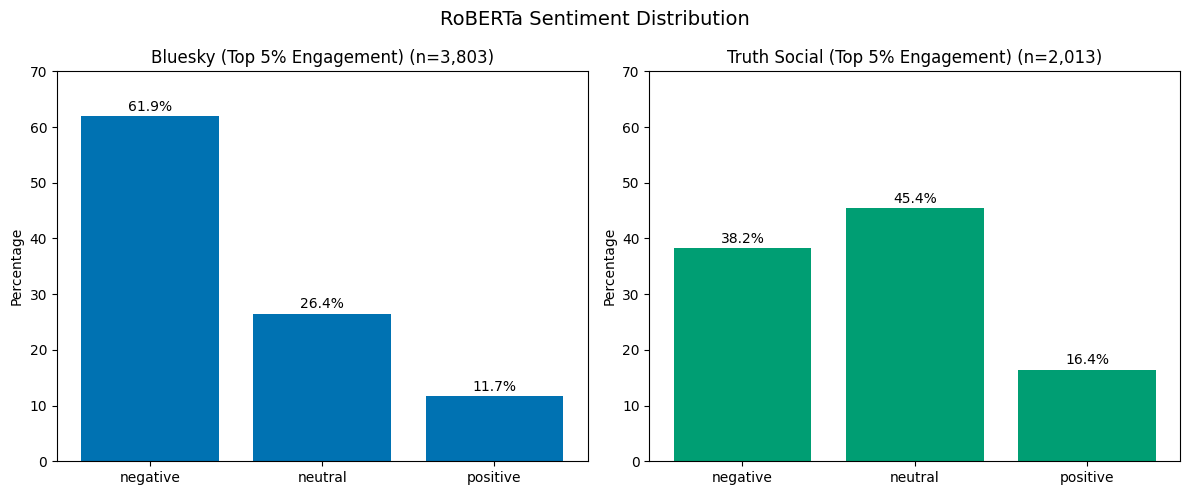

In [79]:
# sentiment bar chart — aligned top 5%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
order = ['negative', 'neutral', 'positive']

for ax, df, name, color in [(ax1, bsky_top, 'Bluesky', c_bsky), (ax2, truth_top, 'Truth Social', c_truth)]:
    counts = df['label'].value_counts().reindex(order, fill_value=0)
    pcts = counts / counts.sum() * 100
    bars = ax.bar(counts.index, pcts.values, color=color)
    ax.set_title(f'{name} (Top 5% Engagement) (n={len(df):,})')
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 70)
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', fontsize=10)

plt.suptitle('RoBERTa Sentiment Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_sentiment_top.png', dpi=150, bbox_inches='tight')
plt.show()

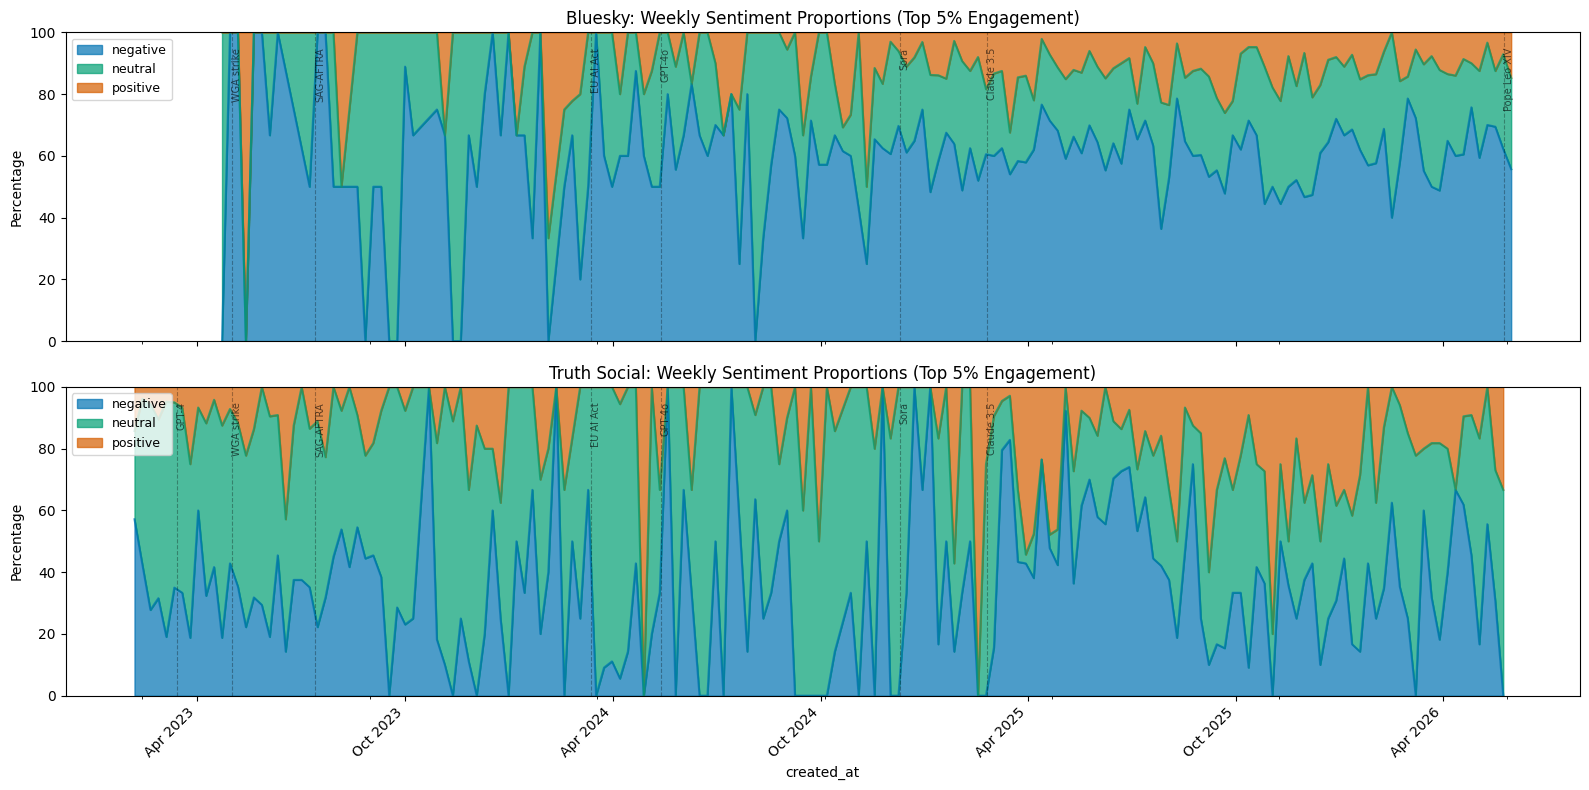

In [58]:
# sentiment over time — aligned top 5%
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, df, name in [(ax1, bsky_top, 'Bluesky'), (ax2, truth_top, 'Truth Social')]:
    weekly = df.set_index('created_at').groupby([pd.Grouper(freq='W'), 'label']).size().unstack(fill_value=0)
    weekly_pct = weekly.div(weekly.sum(axis=1), axis=0) * 100
    weekly_pct.plot.area(ax=ax, alpha=0.7, stacked=True)
    ax.set_title(f'{name}: Weekly Sentiment Proportions (Top 5% Engagement)')
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 100)
    ax.legend(loc='upper left', fontsize=9)

    for date_str, label in AI_EVENTS.items():
        dt = pd.Timestamp(date_str, tz='UTC')
        if dt >= df['created_at'].min() and dt <= df['created_at'].max():
            ax.axvline(dt, color='black', alpha=0.3, linewidth=0.8, linestyle='--')
            ax.text(dt, 95, label, rotation=90, fontsize=7, alpha=0.6, va='top')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_sentiment_over_time_top.png', dpi=150, bbox_inches='tight')
plt.show()

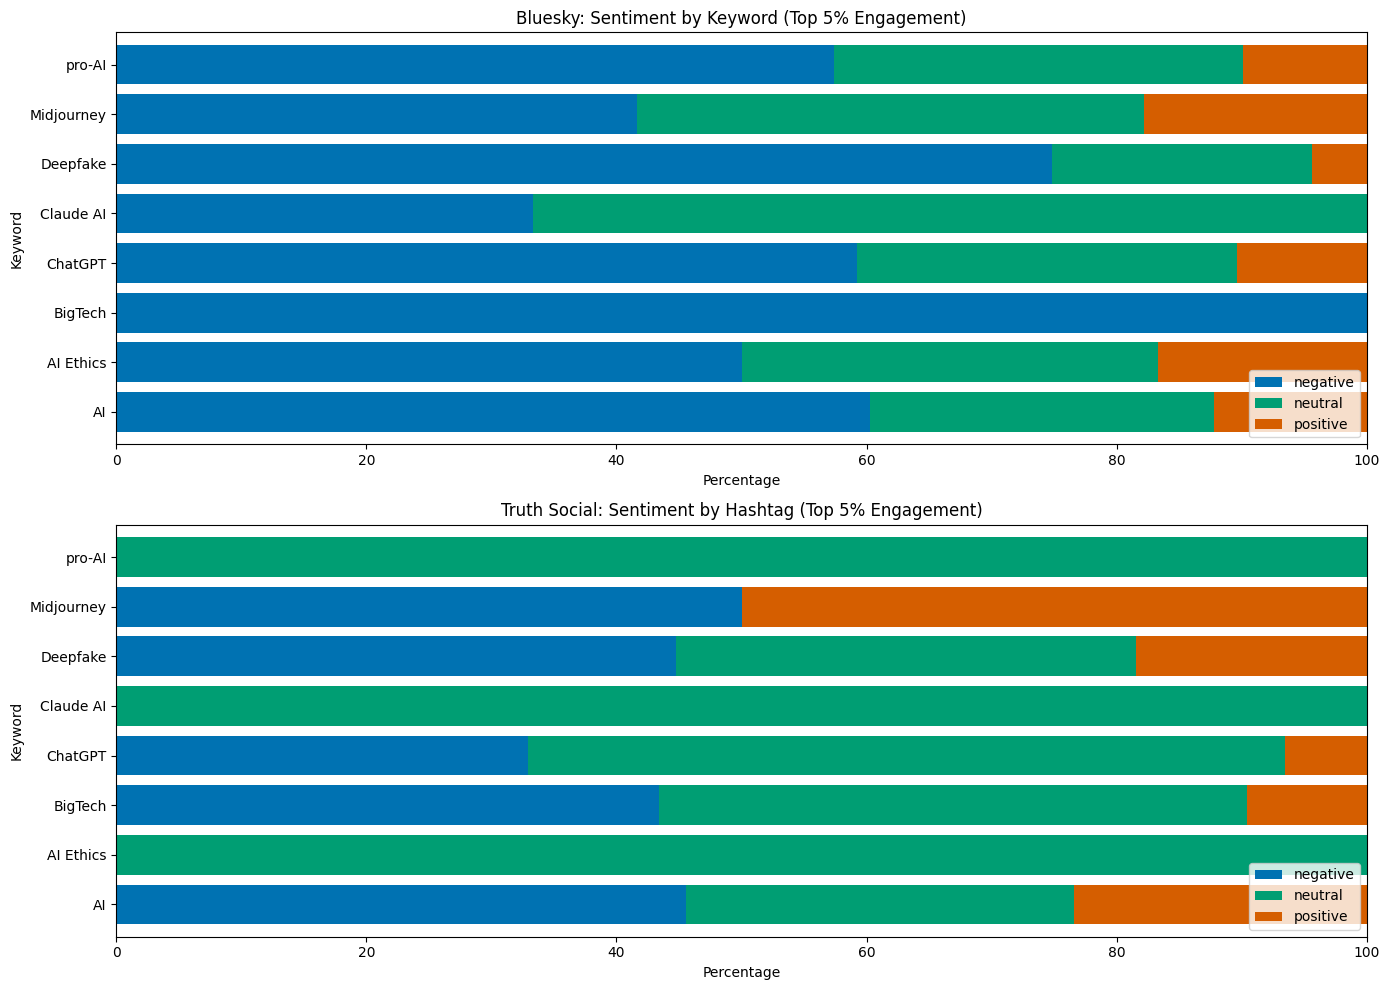

In [83]:
# keyword sentiment 

TRUTH_LABEL_MAP = {
    'AI': 'AI', 'ChatGPT': 'ChatGPT', 'GenAI': 'GenAI', 'Midjourney': 'Midjourney',
    'AIslop': 'AI slop', 'antiAI': 'anti-AI', 'deepfake': 'Deepfake',
    'proAI': 'pro-AI', 'AIpowered': 'AI powered', 'AIagents': 'AI agents',
    'BigTech': 'BigTech', 'AIethics': 'AI Ethics', 'AIenergy': 'AI energy',
    'AIhallucination': 'AI hallucination', 'ClaudeAI': 'Claude AI',
    'AIdatacenter': 'AI datacenter', 'AIbreakthrough': 'AI breakthrough',
    'AIpolarization': 'AI polarization', 'ArtificialIntelligence': 'Artificial Intelligence',
}

truth_top['display_term'] = truth_top['hashtag'].map(TRUTH_LABEL_MAP)

# get shared terms that appear in both top 5% datasets
shared_terms = sorted(set(bsky_top['search_keyword']) & set(truth_top['display_term']))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

bsky_kw_sent = bsky_top.groupby('search_keyword')['label'].value_counts(normalize=True).unstack(fill_value=0) * 100
bsky_kw_sent = bsky_kw_sent.reindex(shared_terms).reindex(columns=['negative', 'neutral', 'positive']).fillna(0)
bsky_kw_sent.plot.barh(ax=ax1, stacked=True, width=0.8)
ax1.set_title('Bluesky: Sentiment by Keyword (Top 5% Engagement)')
ax1.set_xlabel('Percentage')
ax1.set_ylabel('Keyword')
ax1.set_xlim(0, 100)
ax1.legend(loc='lower right')

truth_kw_sent = truth_top.groupby('display_term')['label'].value_counts(normalize=True).unstack(fill_value=0) * 100
truth_kw_sent = truth_kw_sent.reindex(shared_terms).reindex(columns=['negative', 'neutral', 'positive']).fillna(0)
truth_kw_sent.plot.barh(ax=ax2, stacked=True, width=0.8)
ax2.set_title('Truth Social: Sentiment by Hashtag (Top 5% Engagement)')
ax2.set_xlabel('Percentage')
ax2.set_ylabel('Keyword')
ax2.set_xlim(0, 100)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_sentiment_by_keyword_top.png', dpi=150, bbox_inches='tight')
plt.show()

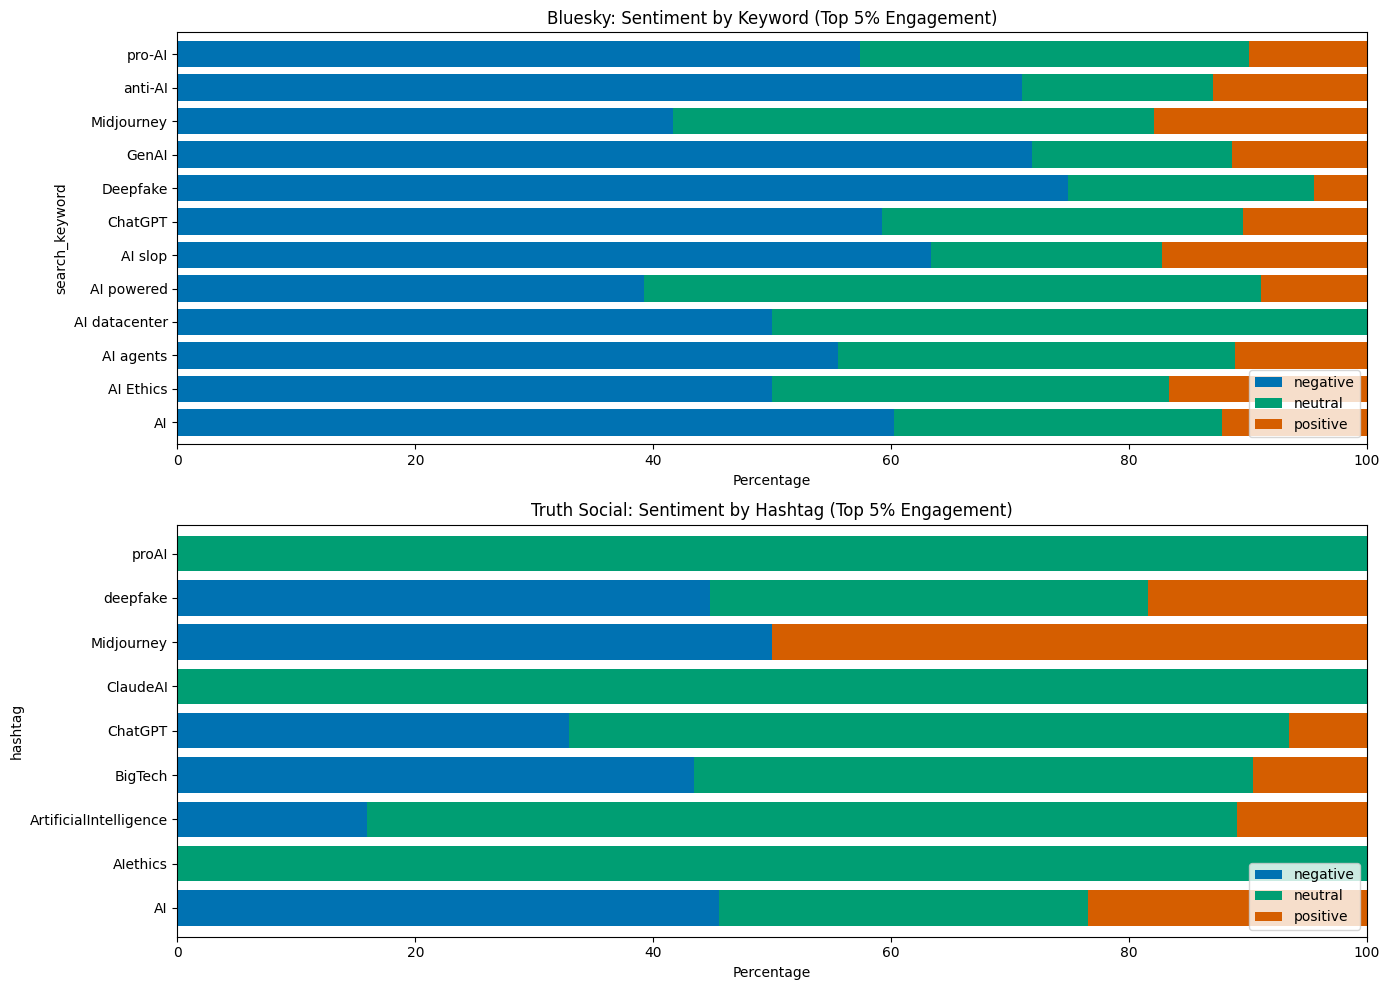

In [59]:
# sentiment by keyword — top 5%
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

bsky_kw_sent = bsky_top.groupby('search_keyword')['label'].value_counts(normalize=True).unstack(fill_value=0) * 100
top_kw = bsky_top['search_keyword'].value_counts().head(12).index
bsky_kw_sent = bsky_kw_sent.loc[bsky_kw_sent.index.isin(top_kw)].reindex(columns=['negative', 'neutral', 'positive'])
bsky_kw_sent.plot.barh(ax=ax1, stacked=True, width=0.8)
ax1.set_title('Bluesky: Sentiment by Keyword (Top 5% Engagement)')
ax1.set_xlabel('Percentage')
ax1.set_xlim(0, 100)
ax1.legend(loc='lower right')

truth_ht_sent = truth_top.groupby('hashtag')['label'].value_counts(normalize=True).unstack(fill_value=0) * 100
top_ht = truth_top['hashtag'].value_counts().head(12).index
truth_ht_sent = truth_ht_sent.loc[truth_ht_sent.index.isin(top_ht)].reindex(columns=['negative', 'neutral', 'positive'])
truth_ht_sent.plot.barh(ax=ax2, stacked=True, width=0.8)
ax2.set_title('Truth Social: Sentiment by Hashtag (Top 5% Engagement)')
ax2.set_xlabel('Percentage')
ax2.set_xlim(0, 100)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_sentiment_by_keyword_top.png', dpi=150, bbox_inches='tight')
plt.show()

## Emotion Analysis

In [60]:
# emotion distribution table — top 5%
EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love',
            'optimism', 'pessimism', 'sadness', 'surprise', 'trust', 'neutral']

bsky_emo_counts = Counter(e for labels in bsky_top['labels'].dropna() for e in labels.split('|'))
truth_emo_counts = Counter(e for labels in truth_top['labels'].dropna() for e in labels.split('|'))
bsky_emo_total = sum(bsky_emo_counts.values())
truth_emo_total = sum(truth_emo_counts.values())

emo_table = pd.DataFrame({
    'Emotion': EMOTIONS,
    'Bluesky (n)': [f"{bsky_emo_counts.get(e, 0):,}" for e in EMOTIONS],
    'Bluesky (%)': [f"{bsky_emo_counts.get(e, 0)/max(bsky_emo_total,1)*100:.1f}%" for e in EMOTIONS],
    'Truth (n)': [f"{truth_emo_counts.get(e, 0):,}" for e in EMOTIONS],
    'Truth (%)': [f"{truth_emo_counts.get(e, 0)/max(truth_emo_total,1)*100:.1f}%" for e in EMOTIONS],
}).sort_values('Bluesky (n)', ascending=False, key=lambda x: x.str.replace(',', '').astype(int))

print(emo_table.to_string(index=False))

     Emotion Bluesky (n) Bluesky (%) Truth (n) Truth (%)
     disgust       2,199       28.8%     1,119     25.2%
       anger       2,168       28.4%     1,199     27.0%
anticipation         891       11.7%       489     11.0%
         joy         795       10.4%       478     10.8%
    optimism         625        8.2%       539     12.1%
     sadness         398        5.2%        65      1.5%
        fear         215        2.8%       478     10.8%
     neutral         209        2.7%        51      1.1%
    surprise          63        0.8%         7      0.2%
        love          37        0.5%         9      0.2%
   pessimism          32        0.4%         5      0.1%
       trust           0        0.0%         1      0.0%


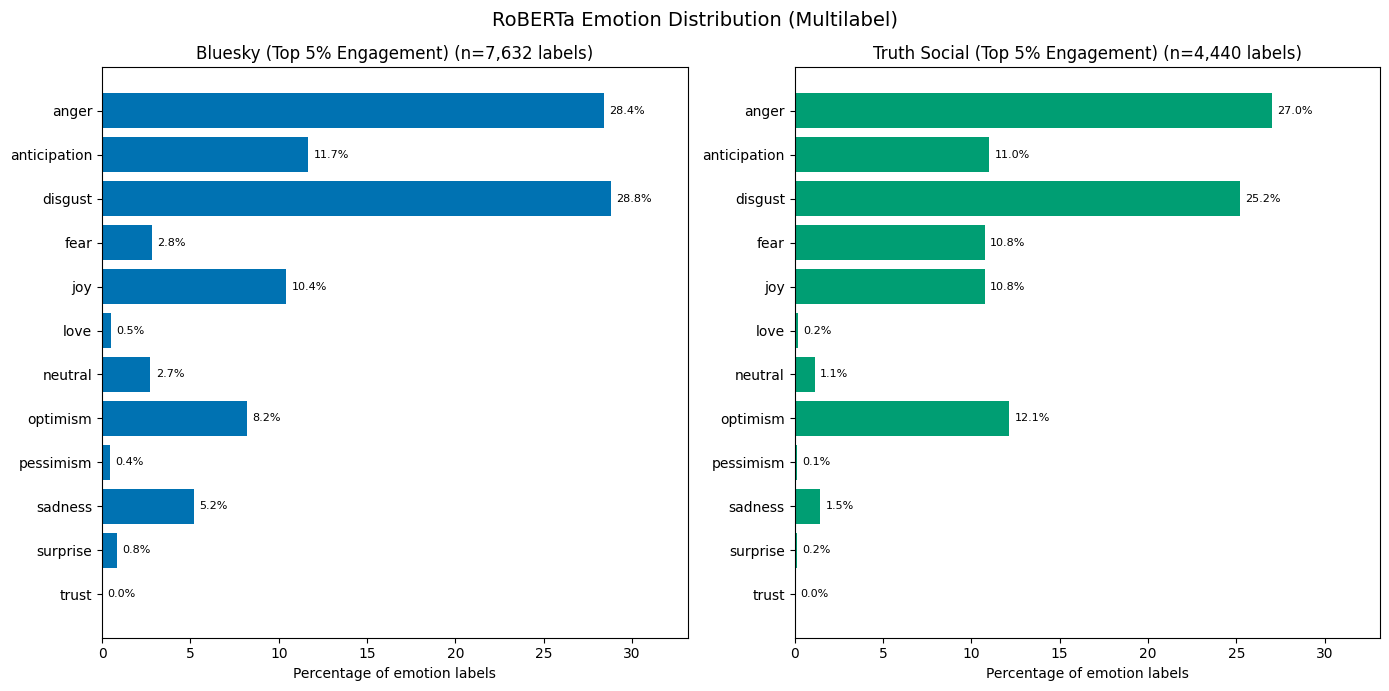

In [84]:
# emotion bar chart
EMOTIONS_ORDER = sorted(set(list(bsky_emo_counts.keys()) + list(truth_emo_counts.keys())))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

for ax, counts, name, color in [(ax1, bsky_emo_counts, 'Bluesky', c_bsky), (ax2, truth_emo_counts, 'Truth Social', c_truth)]:
    total = sum(counts.values())
    pcts = [counts.get(e, 0)/total*100 for e in EMOTIONS_ORDER]

    bars = ax.barh(EMOTIONS_ORDER[::-1], pcts[::-1], color=color)
    ax.set_title(f'{name} (Top 5% Engagement) (n={total:,} labels)')
    ax.set_xlabel('Percentage of emotion labels')
    for bar, pct in zip(bars, pcts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=8)

max_pct = max(max(v/sum(bsky_emo_counts.values())*100 for v in bsky_emo_counts.values()),
              max(v/sum(truth_emo_counts.values())*100 for v in truth_emo_counts.values()))
ax1.set_xlim(0, max_pct * 1.15)
ax2.set_xlim(0, max_pct * 1.15)

plt.suptitle('RoBERTa Emotion Distribution (Multilabel)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_emotion_top.png', dpi=150, bbox_inches='tight')
plt.show()

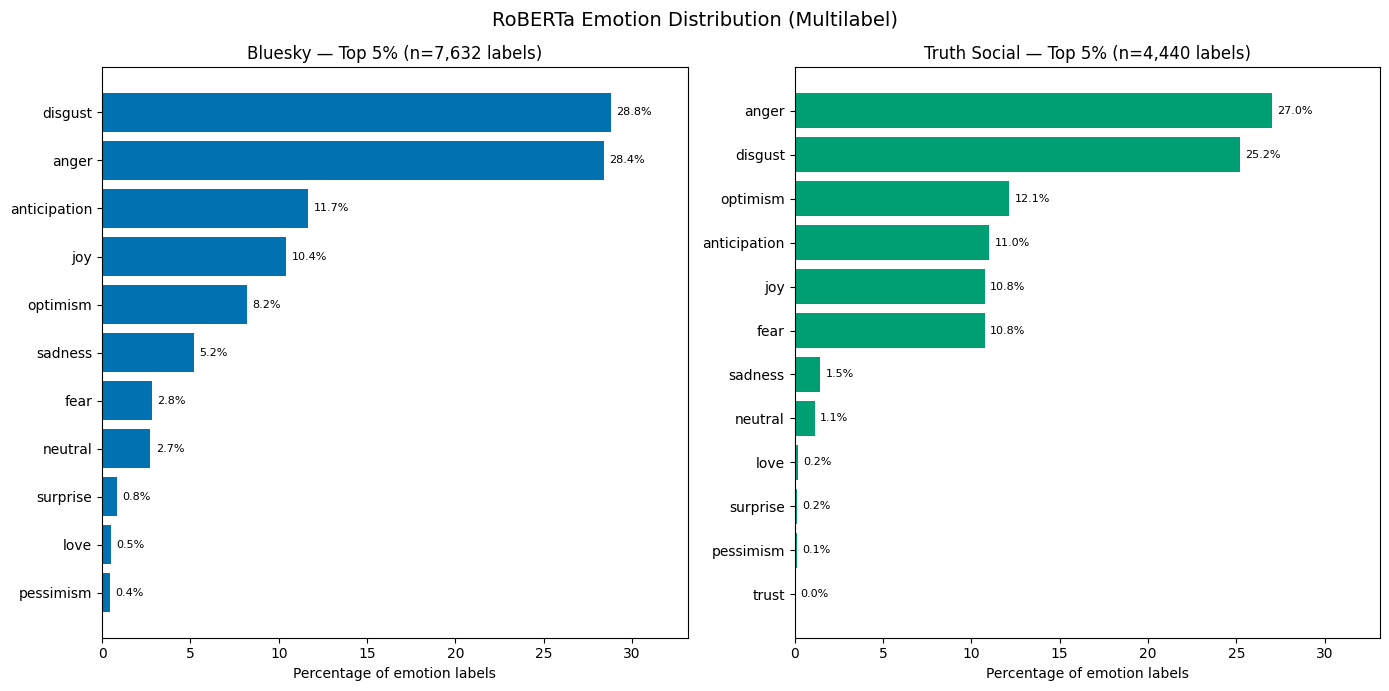

In [61]:
# emotion bar chart - top 5% engagement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

for ax, counts, name, color in [(ax1, bsky_emo_counts, 'Bluesky', c_bsky), (ax2, truth_emo_counts, 'Truth Social', c_truth)]:
    sorted_emo = sorted(counts.items(), key=lambda x: -x[1])
    labels_list = [e[0] for e in sorted_emo]
    values = [e[1] for e in sorted_emo]
    total = sum(values)
    pcts = [v/total*100 for v in values]

    bars = ax.barh(labels_list[::-1], pcts[::-1], color=color)
    ax.set_title(f'{name}: (Top 5% Engagement) (n={sum(counts.values()):,} labels)')
    ax.set_xlabel('Percentage of emotion labels')

    for bar, pct in zip(bars, pcts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', fontsize=8)

max_pct = max(max(v/sum(bsky_emo_counts.values())*100 for v in bsky_emo_counts.values()),
              max(v/sum(truth_emo_counts.values())*100 for v in truth_emo_counts.values()))
ax1.set_xlim(0, max_pct * 1.15)
ax2.set_xlim(0, max_pct * 1.15)

plt.suptitle('RoBERTa Emotion Distribution (Multilabel)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_emotion_top.png', dpi=150, bbox_inches='tight')
plt.show()

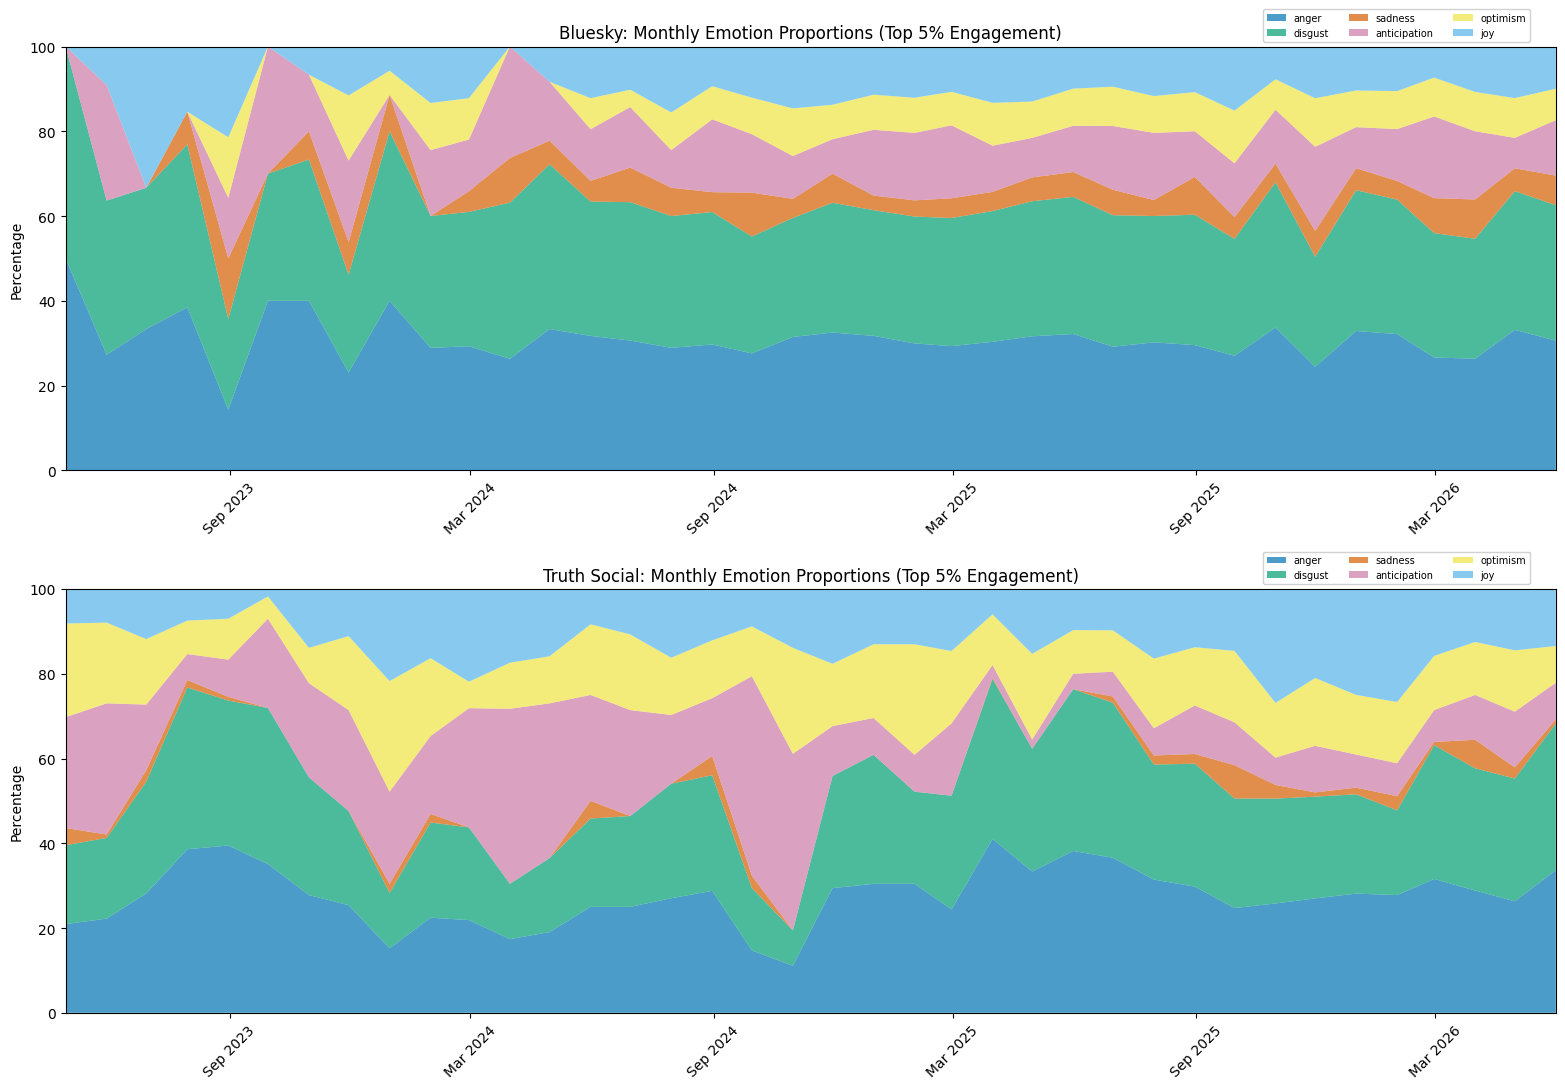

In [97]:
# emotion over time 
EMOTION_ORDER = ['anger', 'disgust', 'sadness', 'anticipation', 'optimism', 'joy']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11))

stored_dates = {}
for ax, df, name in [(ax1, bsky_top, 'Bluesky'), (ax2, truth_top, 'Truth Social')]:
    emo_df = df[['created_at', 'labels']].dropna().copy()
    emo_df['emotion_list'] = emo_df['labels'].str.split('|')
    emo_exploded = emo_df.explode('emotion_list')
    emo_exploded = emo_exploded[emo_exploded['emotion_list'].isin(EMOTION_ORDER)]
    monthly = emo_exploded.set_index('created_at').groupby(
        [pd.Grouper(freq='ME'), 'emotion_list']
    ).size().unstack(fill_value=0)
    monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
    monthly_pct = monthly_pct.reindex(columns=EMOTION_ORDER, fill_value=0)
    dates = monthly_pct.index.tz_localize(None).to_pydatetime()
    stored_dates[name] = dates
    ax.stackplot(dates, *[monthly_pct[col].values for col in monthly_pct.columns],
                 labels=monthly_pct.columns.tolist(), alpha=0.7)
    ax.set_title(f'{name}: Monthly Emotion Proportions (Top 5% Engagement)')
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 100)
    ax.legend(loc='lower left', bbox_to_anchor=(0.8, 1.0), fontsize=7, ncol=3, framealpha=0.9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# align both to Bluesky's actual data range
xlim_start = stored_dates['Bluesky'][0]
xlim_end = stored_dates['Bluesky'][-1]
ax1.set_xlim(xlim_start, xlim_end)
ax2.set_xlim(xlim_start, xlim_end)

plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_emotion_over_time_top.png', dpi=150, bbox_inches='tight')
plt.show()

## MBFC Source Classification

In [63]:
# MBFC classification — full aligned dataset (more URL coverage)
mbfc_path = 'Factual-Reporting-and-Political-Bias-Web-Interactions/data/mbfc.csv'
if os.path.exists(mbfc_path):
    mbfc = pd.read_csv(mbfc_path)
    mbfc_lookup = dict(zip(mbfc['source'], mbfc[['bias', 'factual_reporting']].to_dict('records')))

def extract_urls(text):
    if pd.isna(text):
        return []
    return re.findall(r'https?://[^\s<>"{}|\\^`\[\]]+', str(text))

def extract_domain(url):
    try:
        domain = urlparse(url).netloc.lower()
        return domain[4:] if domain.startswith('www.') else domain
    except:
        return None

def get_mbfc(text):
    for url in extract_urls(text):
        d = extract_domain(url)
        if d and d in mbfc_lookup:
            return mbfc_lookup[d]
    return None

bsky['mbfc'] = bsky['text'].apply(get_mbfc)
bsky['mbfc_bias'] = bsky['mbfc'].apply(lambda x: x['bias'] if x else None)
bsky['mbfc_factuality'] = bsky['mbfc'].apply(lambda x: x['factual_reporting'] if x else None)

truth['mbfc'] = truth['text'].apply(get_mbfc)
truth['mbfc_bias'] = truth['mbfc'].apply(lambda x: x['bias'] if x else None)
truth['mbfc_factuality'] = truth['mbfc'].apply(lambda x: x['factual_reporting'] if x else None)

bsky_classified = bsky[bsky['mbfc_bias'].notna()]
truth_classified = truth[truth['mbfc_bias'].notna()]

print(f"Bluesky MBFC matches:  {len(bsky_classified):,} / {len(bsky):,} ({len(bsky_classified)/len(bsky)*100:.1f}%)")
print(f"Truth MBFC matches:    {len(truth_classified):,} / {len(truth):,} ({len(truth_classified)/len(truth)*100:.1f}%)")

Bluesky MBFC matches:  103 / 75,996 (0.1%)
Truth MBFC matches:    5,226 / 39,759 (13.1%)


In [64]:
# MBFC table — full aligned dataset
bias_order = ['left', 'left-center', 'neutral', 'right-center', 'right']
fact_order = ['high', 'mixed', 'low']

mbfc_table = pd.DataFrame({
    'Category': bias_order + [''] + fact_order,
    'Bluesky (n)': [
        *[f"{(bsky_classified['mbfc_bias']==b).sum():,}" for b in bias_order],
        '',
        *[f"{(bsky_classified['mbfc_factuality']==f).sum():,}" for f in fact_order],
    ],
    'Bluesky (%)': [
        *[f"{(bsky_classified['mbfc_bias']==b).mean()*100:.1f}%" for b in bias_order],
        '',
        *[f"{(bsky_classified['mbfc_factuality']==f).mean()*100:.1f}%" for f in fact_order],
    ],
    'Truth (n)': [
        *[f"{(truth_classified['mbfc_bias']==b).sum():,}" for b in bias_order],
        '',
        *[f"{(truth_classified['mbfc_factuality']==f).sum():,}" for f in fact_order],
    ],
    'Truth (%)': [
        *[f"{(truth_classified['mbfc_bias']==b).mean()*100:.1f}%" for b in bias_order],
        '',
        *[f"{(truth_classified['mbfc_factuality']==f).mean()*100:.1f}%" for f in fact_order],
    ],
})
print(mbfc_table.to_string(index=False))

    Category Bluesky (n) Bluesky (%) Truth (n) Truth (%)
        left          19       18.4%       121      2.3%
 left-center          63       61.2%       453      8.7%
     neutral          17       16.5%       367      7.0%
right-center           4        3.9%       327      6.3%
       right           0        0.0%     3,958     75.7%
                                                        
        high          81       78.6%       606     11.6%
       mixed          22       21.4%     1,839     35.2%
         low           0        0.0%     2,781     53.2%


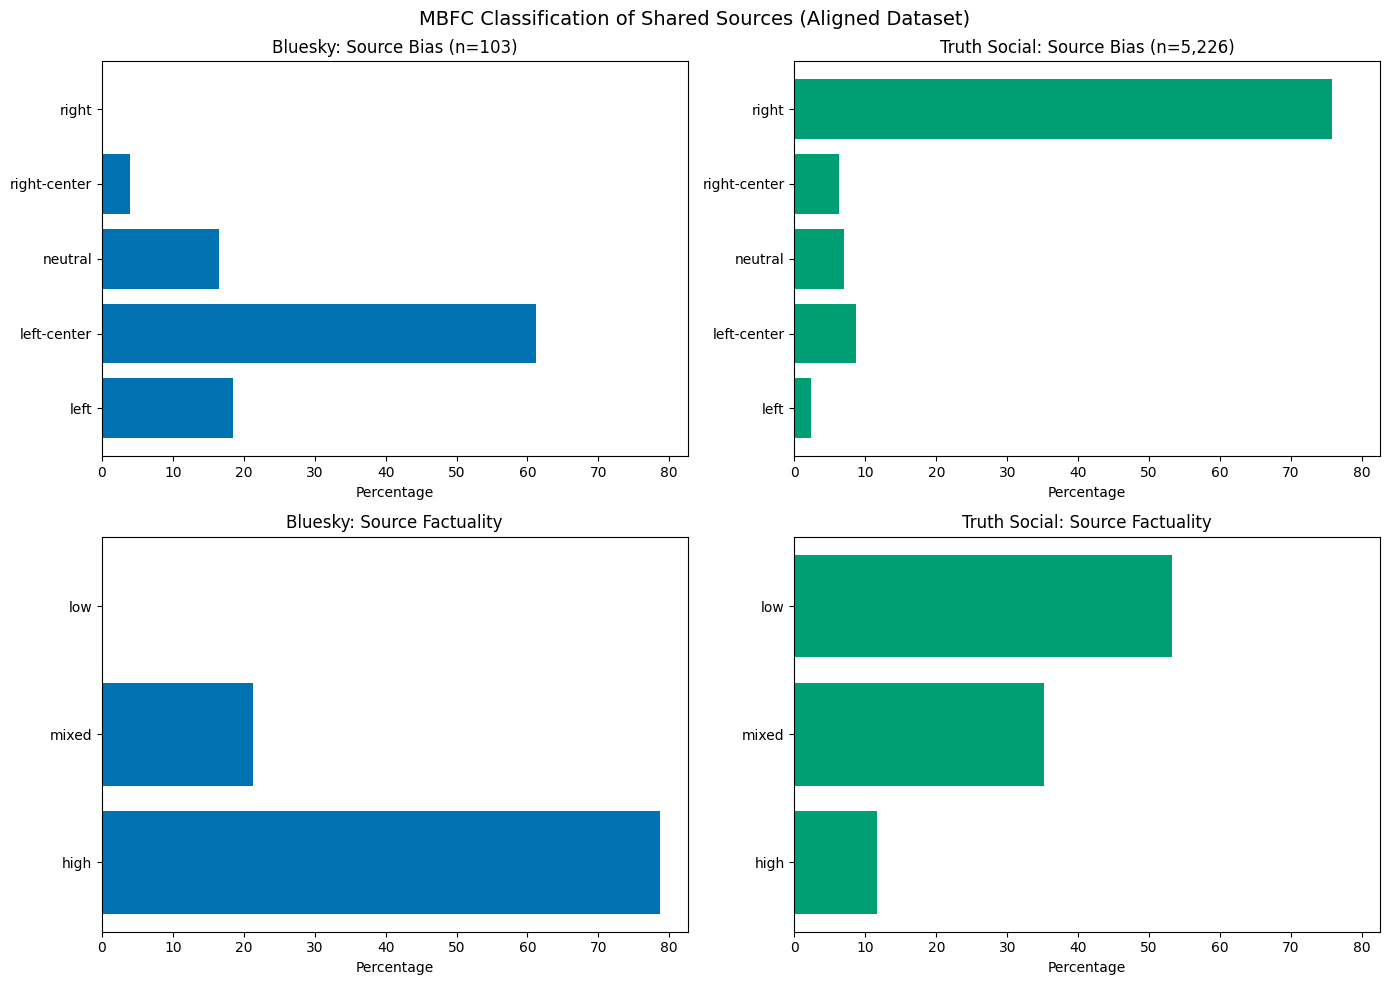

In [65]:
# MBFC charts — full aligned dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (df_c, name, color) in enumerate([(bsky_classified, 'Bluesky', c_bsky), (truth_classified, 'Truth Social', c_truth)]):
    bias = df_c['mbfc_bias'].value_counts().reindex(bias_order, fill_value=0)
    bias_pct = bias / bias.sum() * 100
    axes[0, i].barh(bias.index, bias_pct.values, color=color)
    axes[0, i].set_title(f'{name}: Source Bias (n={len(df_c):,})')
    axes[0, i].set_xlabel('Percentage')

    fact = df_c['mbfc_factuality'].value_counts().reindex(fact_order, fill_value=0)
    fact_pct = fact / fact.sum() * 100
    axes[1, i].barh(fact.index, fact_pct.values, color=color)
    axes[1, i].set_title(f'{name}: Source Factuality')
    axes[1, i].set_xlabel('Percentage')

# consistent x axes
max_bias = max(axes[1, 0].get_xlim()[1], axes[0, 1].get_xlim()[1])
max_fact = max(axes[1, 0].get_xlim()[1], axes[1, 1].get_xlim()[1])
for j in range(2):
    axes[0, j].set_xlim(0, max_bias)
    axes[1, j].set_xlim(0, max_fact)

plt.suptitle('MBFC Classification of Shared Sources (Aligned Dataset)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_mbfc.png', dpi=150, bbox_inches='tight')
plt.show()

## Qwen vs RoBERTa Validation

In [66]:
# cross-model agreement
qwen = pd.read_csv(f'{CLEAN}/qwen_sample_sentiment.csv')
roberta = pd.read_csv(f'{CLEAN}/bsky_top_sentiment.csv')

merged = qwen.merge(roberta, on='post_uri', how='inner', suffixes=('_qwen', '_roberta'))
merged = merged.dropna(subset=['qwen_sentiment', 'label'])

if len(merged) > 0:
    agreement = (merged['qwen_sentiment'] == merged['label']).mean()
    print(f"Overlapping posts: {len(merged):,}")
    print(f"Overall agreement: {agreement:.1%}")
    print(f"\nCrosstab:")
    print(pd.crosstab(merged['qwen_sentiment'], merged['label'], margins=True).to_string())
    print(f"\nPer-class agreement:")
    for s in ['negative', 'neutral', 'positive']:
        mask = merged['label'] == s
        if mask.sum() > 0:
            print(f"  {s}: {(merged.loc[mask, 'qwen_sentiment'] == s).mean():.1%} ({mask.sum():,} posts)")
else:
    print("No overlap between Qwen sample and RoBERTa results")
    print(f"Qwen distribution: {qwen['qwen_sentiment'].value_counts().to_dict()}")
    print(f"RoBERTa distribution: {roberta['label'].value_counts().to_dict()}")

Overlapping posts: 269
Overall agreement: 69.9%

Crosstab:
label           negative  neutral  positive  All
qwen_sentiment                                  
negative             125       33        12  170
neutral               13       49        18   80
positive               2        3        14   19
All                  140       85        44  269

Per-class agreement:
  negative: 89.3% (140 posts)
  neutral: 57.6% (85 posts)
  positive: 31.8% (44 posts)


## Full Aligned Dataset Sentiment (where available)

Full aligned with sentiment — Bluesky: 75,996/75,996 (100.0%)  |  Truth: 39,759/39,759 (100.0%)


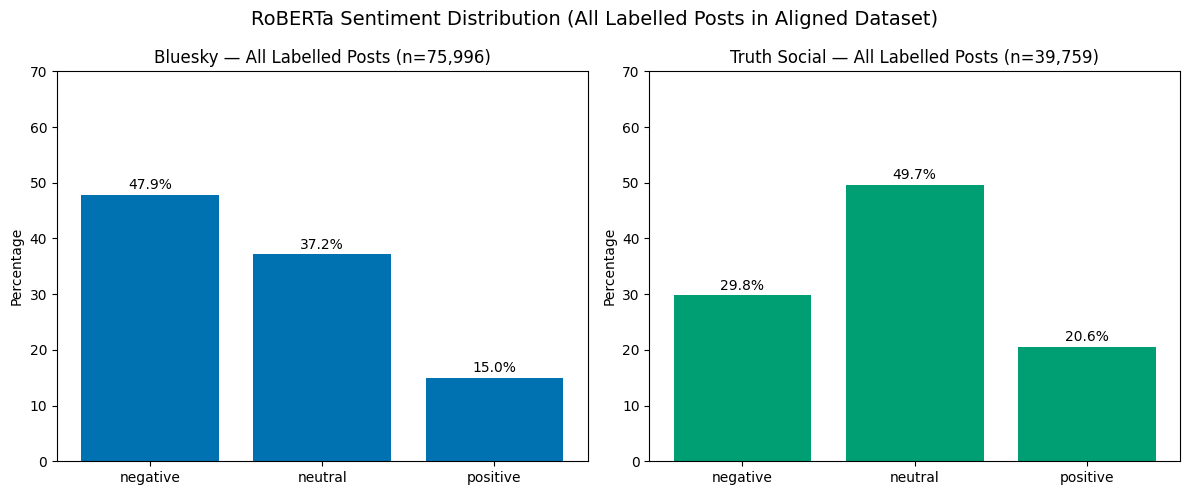

In [67]:
# merge sentiment into full aligned (partial coverage expected)
bsky_full = bsky.merge(bsky_sent, on='post_uri', how='left')
truth_full = truth.merge(truth_sent, on='post_id', how='left')

bsky_has_sent = bsky_full['label'].notna().sum()
truth_has_sent = truth_full['label'].notna().sum()

print(f"Full aligned with sentiment — Bluesky: {bsky_has_sent:,}/{len(bsky_full):,} ({bsky_has_sent/len(bsky_full)*100:.1f}%)  |  Truth: {truth_has_sent:,}/{len(truth_full):,} ({truth_has_sent/len(truth_full)*100:.1f}%)")

# sentiment distribution — full aligned (posts that have labels)
bsky_with = bsky_full[bsky_full['label'].notna()]
truth_with = truth_full[truth_full['label'].notna()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
order = ['negative', 'neutral', 'positive']

for ax, df, name, color in [(ax1, bsky_with, 'Bluesky', c_bsky), (ax2, truth_with, 'Truth Social', c_truth)]:
    counts = df['label'].value_counts().reindex(order, fill_value=0)
    pcts = counts / counts.sum() * 100
    bars = ax.bar(counts.index, pcts.values, color=color)
    ax.set_title(f'{name} — All Labelled Posts (n={len(df):,})')
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 70)
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', fontsize=10)

plt.suptitle('RoBERTa Sentiment Distribution (All Labelled Posts in Aligned Dataset)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{CLEAN}/fig_sentiment_full.png', dpi=150, bbox_inches='tight')
plt.show()

## Topic Modelling + Sentiment Quality

In [98]:
## topic model quality



topic_model_bsky = BERTopic.load(f'{CLEAN}/bsky_top_bertopic_model')
topic_model_truth = BERTopic.load(f'{CLEAN}/truth_top_bertopic_model')

bsky_top_text = pd.read_csv(f'{CLEAN}/bsky_aligned_top.csv')['text'].dropna().apply(
    lambda t: ' '.join([w for w in str(t).lower().split() if len(w) > 2])
)
truth_top_text = pd.read_csv(f'{CLEAN}/truth_aligned_top.csv', dtype={'post_id': str})['text'].dropna().apply(
    lambda t: ' '.join([w for w in str(t).lower().split() if len(w) > 2])
)

for name, model, texts in [('Bluesky', topic_model_bsky, bsky_top_text),
                            ('Truth', topic_model_truth, truth_top_text)]:
    tok = [doc.split() for doc in texts.tolist()]
    d = Dictionary(tok)
    tw = []
    topic_ids = []
    for tid in sorted(set(model.topics_)):
        if tid == -1:
            continue
        words = model.get_topic(tid)
        if words:
            tw.append([w[0] for w in words[:10]])
            topic_ids.append(tid)
    cm = CoherenceModel(topics=tw, texts=tok, dictionary=d, coherence='c_v')
    overall = cm.get_coherence()
    per_topic = cm.get_coherence_per_topic()
    outlier_pct = (pd.Series(model.topics_) == -1).mean() * 100
    n_topics = len(set(model.topics_)) - 1

    print(f"\n{name}")
    print(f"  Topics: {n_topics}, Outliers: {outlier_pct:.1f}%")
    print(f"  Overall c_v coherence: {overall:.4f}")
    for tid, score, words in zip(topic_ids, per_topic, tw):
        print(f"  Topic {tid}: {score:.4f} | {', '.join(words[:6])}")


Bluesky
  Topics: 49, Outliers: 52.3%
  Overall c_v coherence: 0.4216
  Topic 0: 1.0000 | aiart, midjourney, digitalart, aiartcommunity, synthart, aiartwork
  Topic 1: 0.3555 | data, water, students, data center, center, centers
  Topic 2: 0.3116 | chatgpt, asked, asked chatgpt, openai, write, chatgpt asked
  Topic 3: 0.2924 | search, google, deepfake, musk, elon, chatgpt
  Topic 4: 0.3930 | genai, games, game, ghibli, fuck, art
  Topic 5: 0.6463 | art, share, nsfw, artists, tag, tutorials
  Topic 6: 0.4779 | anti, fascist, polarization, pro, fascism, trump
  Topic 7: 0.4024 | que, est, pro, das, dos, der
  Topic 8: 0.3120 | copyright, book, books, disney, writing, authors
  Topic 9: 0.3115 | slop, slop slop, pinterest, posting, posting slop, post slop
  Topic 10: 0.4714 | gay, cock, bear, daddy, grandpa, mature
  Topic 11: 0.4206 | agents, adobe, siri, apple, agent, microsoft
  Topic 12: 0.0650 | synthart, midjourney, caturday, gemini, aiart aiartcommunity, cat
  Topic 13: 0.4182 | h

In [105]:
## model validation - topic coherence

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from bertopic import BERTopic

topic_model_bsky = BERTopic.load(f'{CLEAN}/bsky_top_bertopic_model')
topic_model_truth = BERTopic.load(f'{CLEAN}/truth_top_bertopic_model')

bsky_texts = pd.read_csv(f'{CLEAN}/bsky_aligned_top.csv')['text'].dropna().apply(
    lambda t: ' '.join([w for w in str(t).lower().split() if len(w) > 2])
)
truth_texts = pd.read_csv(f'{CLEAN}/truth_aligned_top.csv', dtype={'post_id': str})['text'].dropna().apply(
    lambda t: ' '.join([w for w in str(t).lower().split() if len(w) > 2])
)

for name, model, texts in [('Bluesky', topic_model_bsky, bsky_texts),
                            ('Truth Social', topic_model_truth, truth_texts)]:
    tok = [doc.split() for doc in texts.tolist()]
    d = Dictionary(tok)
    tw = []
    topic_ids = []
    for tid in sorted(set(model.topics_)):
        if tid == -1:
            continue
        words = model.get_topic(tid)
        if words:
            tw.append([w[0] for w in words[:10]])
            topic_ids.append(tid)

    cm = CoherenceModel(topics=tw, texts=tok, dictionary=d, coherence='c_v')
    overall = cm.get_coherence()
    per_topic = cm.get_coherence_per_topic()
    outlier_pct = (pd.Series(model.topics_) == -1).mean() * 100
    n_topics = len(set(model.topics_)) - 1

    print(f"\n{name}")
    print(f"  Topics: {n_topics}, Outliers: {outlier_pct:.1f}%")
    print(f"  Overall c_v coherence: {overall:.4f}")
    print(f"  Top 5 by coherence:")
    scored = sorted(zip(topic_ids, per_topic, tw), key=lambda x: -x[1])
    for tid, score, words in scored[:5]:
        count = (pd.Series(model.topics_) == tid).sum()
        print(f"    Topic {tid} ({count:,}): {score:.4f} | {', '.join(words[:6])}")


Bluesky
  Topics: 49, Outliers: 52.3%
  Overall c_v coherence: 0.4216
  Top 5 by coherence:
    Topic 0 (8,417): 1.0000 | aiart, midjourney, digitalart, aiartcommunity, synthart, aiartwork
    Topic 34 (27): 1.0000 | stablediffusion, aiart, birthday, , , 
    Topic 5 (1,665): 0.6463 | art, share, nsfw, artists, tag, tutorials
    Topic 19 (170): 0.5648 | stickers, etsy, sticker, shirt, funding, goal
    Topic 35 (26): 0.5525 | gambling, bingo, card, sports, cards, write book

Truth Social
  Topics: 8, Outliers: 0.0%
  Overall c_v coherence: 0.2266
  Top 5 by coherence:
    Topic 4 (181): 0.5074 | cartman, southpark, eric, kyle, blaming, sings
    Topic 0 (43,652): 0.2764 | amp, trump, quot, apos, bigtech, china
    Topic 2 (1,960): 0.2605 | artificialintelligence, glitch, saturn, moon, quot, chatgpt
    Topic 8 (177): 0.2481 | business, success, smallbusiness, smallbiz, marketing, realtor
    Topic 7 (77): 0.2323 | filmfreeway, producers, writers, gala, screenwriting, carpet


In [104]:
## model validation - emotion

qwen_emo = pd.read_csv(f'{CLEAN}/qwen_sample_complete.csv')
roberta_emo = pd.read_csv(f'{CLEAN}/bsky_top_emotions.csv')
merged_emo = qwen_emo[['post_uri', 'qwen_emotions']].merge(roberta_emo, on='post_uri', how='inner')
merged_emo = merged_emo.dropna(subset=['qwen_emotions', 'labels'])

EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love',
            'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

if len(merged_emo) > 0:
    # per-emotion agreement
    print(f"RoBERTa vs Qwen Emotion (n={len(merged_emo):,})\n")
    print(f"{'Emotion':<15} {'Agreement':>10} {'Both Yes':>10} {'RoBERTa Only':>13} {'Qwen Only':>10}")

    agreements = []
    for emo in EMOTIONS:
        roberta_has = merged_emo['labels'].str.contains(emo, na=False)
        qwen_has = merged_emo['qwen_emotions'].str.contains(emo, na=False)
        agree = (roberta_has == qwen_has).mean()
        both = (roberta_has & qwen_has).sum()
        rob_only = (roberta_has & ~qwen_has).sum()
        qwen_only = (~roberta_has & qwen_has).sum()
        agreements.append(agree)
        print(f"  {emo:<13} {agree:>9.1%} {both:>10,} {rob_only:>13,} {qwen_only:>10,}")

    print(f"\n  Mean per-emotion agreement: {np.mean(agreements):.1%}")
else:
    print("No overlapping posts found")

RoBERTa vs Qwen Emotion (n=269)

Emotion          Agreement   Both Yes  RoBERTa Only  Qwen Only
  anger             79.6%         87            39         16
  anticipation      72.5%          6            71          3
  disgust           58.4%         37            93         19
  fear              80.3%         11             0         53
  joy               80.7%         43            43          9
  love              97.8%          2             2          4
  optimism          80.7%         31            22         30
  pessimism         72.9%          1             0         73
  sadness           70.6%         19             3         76
  surprise          63.6%          2             1         97
  trust             56.5%          0             0        117

  Mean per-emotion agreement: 73.9%


In [102]:
## sentiment model quality



# cross-model agreement
roberta = pd.read_csv(f'{CLEAN}/bsky_top_sentiment.csv')
qwen = pd.read_csv(f'{CLEAN}/qwen_sample_sentiment.csv')
merged = qwen.merge(roberta, on='post_uri', how='inner').dropna(subset=['qwen_sentiment', 'label'])

print(f"RoBERTa vs Qwen Comparison (n={len(merged):,})")
print(f"Accuracy: {(merged['qwen_sentiment'] == merged['label']).mean():.1%}")
print(f"Cohen's kappa: {cohen_kappa_score(merged['label'], merged['qwen_sentiment']):.3f}")
print(f"\n{classification_report(merged['qwen_sentiment'], merged['label'])}")


RoBERTa vs Qwen Comparison (n=269)
Accuracy: 69.9%
Cohen's kappa: 0.468

              precision    recall  f1-score   support

    negative       0.89      0.74      0.81       170
     neutral       0.58      0.61      0.59        80
    positive       0.32      0.74      0.44        19

    accuracy                           0.70       269
   macro avg       0.60      0.69      0.61       269
weighted avg       0.76      0.70      0.72       269



## Compute Resources

In [68]:
# compute log
compute = pd.DataFrame({
    'Task': [
        'Data collection (Bluesky)',
        'Data collection (Truth Social)',
        'Data cleaning',
        'RoBERTa sentiment (top 5%)',
        'RoBERTa emotion (top 5%)',
        'BERTopic (top 5%)',
        'Qwen 2.5 14B (5K sample)',
        'MBFC classification',
    ],
    'Hardware': [
        'MacBook M4',
        'MacBook M4',
        'MacBook M4',
        'HPC Tesla T4 (15.6 GB)',
        'HPC Tesla T4 (15.6 GB)',
        'HPC Tesla T4 (15.6 GB)',
        'MacBook M4 (10.7 GB, Ollama)',
        'MacBook M4',
    ],
    'Time': [
        'Multiple sessions',
        'Multiple sessions',
        '~30 min',
        '4.7 + 7.0 min',
        '4.7 + 6.9 min',
        '5.4 min',
        '~3 hours',
        '~5 min',
    ],
    'Posts': [
        '1,529,104',
        '48,086',
        '~1.6M',
        '76,557 + 48,086',
        '76,557 + 48,086',
        '75,243 + 47,127',
        '5,000',
        '~116K',
    ],
})
print(compute.to_string(index=False))

                          Task                     Hardware              Time           Posts
     Data collection (Bluesky)                   MacBook M4 Multiple sessions       1,529,104
Data collection (Truth Social)                   MacBook M4 Multiple sessions          48,086
                 Data cleaning                   MacBook M4           ~30 min           ~1.6M
    RoBERTa sentiment (top 5%)       HPC Tesla T4 (15.6 GB)     4.7 + 7.0 min 76,557 + 48,086
      RoBERTa emotion (top 5%)       HPC Tesla T4 (15.6 GB)     4.7 + 6.9 min 76,557 + 48,086
             BERTopic (top 5%)       HPC Tesla T4 (15.6 GB)           5.4 min 75,243 + 47,127
      Qwen 2.5 14B (5K sample) MacBook M4 (10.7 GB, Ollama)          ~3 hours           5,000
           MBFC classification                   MacBook M4            ~5 min           ~116K
